```text
First LGD experiments
├── Import & Setup
├── Limitation
└── LGD estimation
    ├── Explore
    ├── Fit & Evaluate
    ├── Transform
    └── Export
```

#### Import & Setup 

In [1]:
# Init work dir

from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
# Standard modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Framework

from src.feature_engineering import create_target_def12, SpecialMappings
from src.metrics import my_regression_metrics
from src.modelling import fit_lgd, transform_lgd
from src.plots import compare_lgd_distributions, explore_variable, variable_vs_lgd 
from src.preprocessing import my_input_load, my_time_split, ReplaceMinusOne
from src.validation import model_selector, missing_summary

# ML modules

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Configuration

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)
from sklearn import set_config; set_config(transform_output="pandas")

In [3]:
# load input file

full_dataset = my_input_load(2019, 2020)

# create def12

full_dataset, dr_summary = create_target_def12(full_dataset)

# split train/test

windows = {"train": (2019, 2019), "test":  (2020, 2020)}

splits = my_time_split(full_dataset, "LoanYear", windows)

ds_trai = splits["train"]["df"]
ds_test = splits["test"]["df"]

LoanDate range:     2019-01-01 00:00:00 2020-12-31 00:00:00
+12 months:         2020-01-01 00:00:00 2021-12-31 00:00:00
DefaultDate range:  2019-04-26 00:00:00 2023-10-13 00:00:00


LoanYear,num_loans,num_defaults,default_rate
2019,28487,4879,0.171271
2020,19959,2294,0.114936



SPLIT SUMMARY

TRAIN
Years        : 2019 - 2019
Shape (X, y) : (28487, 105), (28487,)

LoanYear distribution
LoanYear
2019    28487
Name: count, dtype: int64

Default rate : 0.1713
------------------------------------------------------------

TEST
Years        : 2020 - 2020
Shape (X, y) : (19959, 105), (19959,)

LoanYear distribution
LoanYear
2020    19959
Name: count, dtype: int64

Default rate : 0.1149
------------------------------------------------------------


#### Limitation


Analysis reveals a structural change in the LossGivenDefault variable across loan origination years. While the period **2019–2020** contains zero-loss observations (full-recoveries), earlier and later years show higher and constrained LGD values, suggesting differences in the underlying target definition or calculation methodology. Since the objective of this project is to demonstrate a modular LGD estimation rather than validate the dataset itself, LossGivenDefault is treated as the observed target variable, and the LGD models are developed on the 2019–2020 period, where the target behaves consistently.

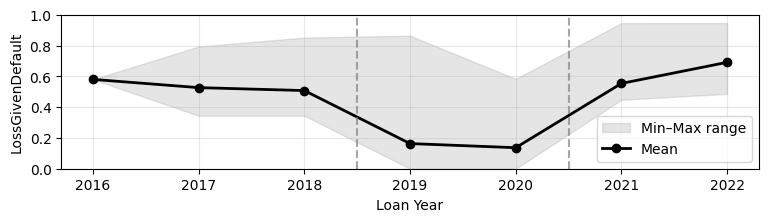

In [4]:
# explore "LossGivenDefault" across years

explore_variable(variable="LossGivenDefault", yr_start=2016, yr_end=2022, breaks=[2018.5, 2020.5])

#### Pre-processing (independent from PD pipeline)

In [5]:
# load input file

columns_to_use = [
    "LossGivenDefault", # the target here
    "DefaultDate", # needed
    "FirstPaymentDate", # needed
    "LoanApplicationStartedDate", # needed
    "LoanDate", # needed
    "Country", # needed
    "Age",
    "Gender",
    "Amount",
    "Interest",
    "LoanDuration",
    "Education",
    "EmploymentDurationCurrentEmployer",
    "HomeOwnershipType",
    "IncomeTotal",
    "ExistingLiabilities",
    "LiabilitiesTotal",
    "CreditScoreEeMini",
    "NoOfPreviousLoansBeforeLoan",
    "AmountOfPreviousLoansBeforeLoan",
    "PreviousRepaymentsBeforeLoan",
    #"EmploymentStatus", empty
    "LanguageCode",
    #"MaritalStatus", empty
    "NewCreditCustomer", 
    #"OccupationArea", empty   
    #"UseOfLoan", empty        
    "VerificationType",
]

full_dataset = my_input_load(2019, 2020, columns_to_use=columns_to_use)

In [6]:
# REPLACE MISSING VALUES (-1) WITH NAN

replacer = ReplaceMinusOne(verbose=True)
full_dataset = replacer.fit_transform(full_dataset)

In [7]:
# CREATE def12 VARIABLE

full_dataset, dr_summary = create_target_def12(full_dataset)

LoanDate range:     2019-01-01 00:00:00 2020-12-31 00:00:00
+12 months:         2020-01-01 00:00:00 2021-12-31 00:00:00
DefaultDate range:  2019-04-26 00:00:00 2023-10-13 00:00:00


LoanYear,num_loans,num_defaults,default_rate
2019,28487,4879,0.171271
2020,19959,2294,0.114936


In [8]:
# TRAIN/TEST SPLIT

windows = {"train": (2019, 2019), "test":  (2020, 2020)}

splits = my_time_split(full_dataset, "LoanYear", windows, target="LossGivenDefault")

X_trai = splits["train"]["X"]
y_trai = splits["train"]["y"]
X_test = splits["test"]["X"]
y_test = splits["test"]["y"]


SPLIT SUMMARY

TRAIN
Years        : 2019 - 2019
Shape (X, y) : (28487, 19), (28487,)

LoanYear distribution
LoanYear
2019    28487
Name: count, dtype: int64

Default rate : 0.1633
------------------------------------------------------------

TEST
Years        : 2020 - 2020
Shape (X, y) : (19959, 19), (19959,)

LoanYear distribution
LoanYear
2020    19959
Name: count, dtype: int64

Default rate : 0.1365
------------------------------------------------------------


In [9]:
# DEFINE PURE CATEGORICAL VARIABLES

categorical_variables = [
    "Education",         # 1,2,3,4,5
    #"EmploymentStatus",  # 1,2,3,4,5,6
    "Gender",            # 0,1,2
    "HomeOwnershipType", # 0-10
    "LanguageCode",      # 1,2,3,4,5,6,9
    #"MaritalStatus",     # 1-5
    "NewCreditCustomer", # 0,1
    #"OccupationArea",    # 1-19
    #"UseOfLoan",         # 0-8
    "VerificationType"   # 0-4
]

for col in categorical_variables:
    X_trai[col] = X_trai[col].astype("category")
    X_test[col] = X_test[col].astype("category")

# separate nums/cats
cat_cols = X_trai.select_dtypes(include=["category"]).columns
num_cols = X_trai.select_dtypes(exclude=["category"]).columns

In [10]:
# special mappings

mapper = SpecialMappings(verbose=False)

print("=== TRAIN ===")
X_trai = mapper.fit_transform(X_trai)

print("=== TEST ===")
X_test = mapper.transform(X_test)

=== TRAIN ===
=== TEST ===


In [11]:
# missing values

print("=== TRAIN ===")
print(missing_summary(X_trai))
print("=== TEST ===")
print(missing_summary(X_test))

=== TRAIN ===
                                   missing_count  missing_percent
PreviousRepaymentsBeforeLoan               10155        35.647839
EmploymentDurationCurrentEmployer           1444         5.068979
CreditScoreEeMini                              1         0.003510
Age                                            0         0.000000
LanguageCode                                   0         0.000000
VerificationType                               0         0.000000
NoOfPreviousLoansBeforeLoan                    0         0.000000
NewCreditCustomer                              0         0.000000
LoanDuration                                   0         0.000000
LiabilitiesTotal                               0         0.000000
IncomeTotal                                    0         0.000000
Interest                                       0         0.000000
Amount                                         0         0.000000
HomeOwnershipType                              0         0.000

In [12]:
# impute

imputer = SimpleImputer(strategy="median")

X_trai[num_cols] = imputer.fit_transform(X_trai[num_cols])
X_test[num_cols] = imputer.transform(X_test[num_cols])

imputer = SimpleImputer(strategy="most_frequent")

X_trai[cat_cols] = imputer.fit_transform(X_trai[cat_cols])
X_test[cat_cols] = imputer.transform(X_test[cat_cols])

# scale for regression

scaler = StandardScaler()

X_trai_scaled = X_trai.copy()
X_test_scaled = X_test.copy()

X_trai_scaled[num_cols] = scaler.fit_transform(X_trai_scaled[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test_scaled[num_cols])

In [13]:
print('SHAPES')
print(X_trai.shape)
print(y_trai.shape)
print(X_test.shape)
print(y_test.shape)

SHAPES
(28487, 19)
(28487,)
(19959, 19)
(19959,)


## LGD estimation

#### Explore

In [14]:
# explore lgd & recovery

columns_to_explore = [
    "Age",
    "Gender",
    "Amount",
    "Interest",
    "LoanDuration",
    "Education",
    "EmploymentDurationCurrentEmployer",
    "HomeOwnershipType",
    "IncomeTotal",
    "ExistingLiabilities",
    "LiabilitiesTotal",
    "CreditScoreEeMini",
    "NoOfPreviousLoansBeforeLoan",
    "AmountOfPreviousLoansBeforeLoan",
    "PreviousRepaymentsBeforeLoan"
]

for variable in columns_to_explore:
    if splits["train"]["df"][variable].nunique() <= 20:
        print(variable)
        variable_vs_lgd(splits["train"]["df"], variable)

Gender


,Gender,count,LGD(mean),LGD=0,LGD>0,Recovery(%)
0,0.000000,3486,0.224,1950,1536,55.938
1,1.000000,1393,0.067,1234,159,88.586


LoanDuration


,LoanDuration,count,LGD(mean),LGD=0,LGD>0,Recovery(%)
0,6,7,0.059,6,1,85.714
1,9,12,0.000,12,0,100.000
2,12,20,0.158,13,7,65.000
3,18,29,0.033,27,2,93.103
4,24,45,0.150,31,14,68.889
5,30,41,0.127,31,10,75.610
6,36,2007,0.183,1261,746,62.830
7,48,197,0.197,119,78,60.406
8,60,2521,0.179,1684,837,66.799


Education


...

,EmploymentDurationCurrentEmployer,count,LGD(mean),LGD=0,LGD>0,Recovery(%)
0,MoreThan5Years,1234,0.192,767,467,62.156
1,Other,248,0.159,172,76,69.355
2,Retiree,277,0.198,175,102,63.177
3,TrialPeriod,17,0.375,5,12,29.412
4,UpTo1Year,1343,0.186,870,473,64.780
5,UpTo2Years,59,0.242,30,29,50.847
6,UpTo3Years,44,0.252,21,23,47.727
7,UpTo4Years,13,0.259,6,7,46.154
8,UpTo5Years,1644,0.158,1138,506,69.221


HomeOwnershipType


,HomeOwnershipType,count,LGD(mean),LGD=0,LGD>0,Recovery(%)
0,1.000000,1774,0.191,1120,654,63.134
1,2.000000,1108,0.176,737,371,66.516
2,3.000000,1149,0.158,802,347,69.800
3,4.000000,24,0.271,11,13,45.833
4,5.000000,58,0.228,33,25,56.897
5,6.000000,14,0.338,5,9,35.714
6,7.000000,28,0.338,9,19,32.143
7,8.000000,212,0.193,118,94,55.660
8,9.000000,5,0.323,1,4,20.000
9,10.000000,507,0.165,348,159,68.639


CreditScoreEeMini


,CreditScoreEeMini,count,LGD(mean),LGD=0,LGD>0,Recovery(%)
0,500.000000,21,0.118,16,5,76.190
1,600.000000,244,0.138,173,71,70.902
2,700.000000,258,0.172,176,82,68.217
3,800.000000,601,0.164,419,182,69.717
4,900.000000,393,0.187,257,136,65.394
5,1000.000000,3362,0.185,2143,1219,63.742


#### Fit & Evaluate

In [17]:
# initialise experiments

experiments = [
    ("experiment A", "historical_avg", None),
    ("experiment B", "univariate", "Age"),
    ("experiment C", "univariate", "Gender"),
    ("experiment D", "univariate", "Amount"),
    ("experiment E", "univariate", "Interest"),
    ("experiment F", "univariate", "LoanDuration"),
    ("experiment G", "univariate", "Education"),
    ("experiment H", "univariate", "EmploymentDurationCurrentEmployer"),
    ("experiment I", "univariate", "HomeOwnershipType"),
    ("experiment J", "univariate", "IncomeTotal"),
    ("experiment K", "univariate", "ExistingLiabilities"),
    ("experiment L", "univariate", "LiabilitiesTotal"),
    ("experiment M", "univariate", "CreditScoreEeMini"),
    ("experiment N", "univariate", "NoOfPreviousLoansBeforeLoan"),
    ("experiment O", "univariate", "AmountOfPreviousLoansBeforeLoan"),
    #("experiment P", "univariate", "PreviousRepaymentsBeforeLoan"),
]

experiment_metrics = []

# reassemble dataframes

ds_trai = pd.concat([X_trai, y_trai], axis=1)
ds_test = pd.concat([X_test, y_test], axis=1)

LGD estimation method: historical_avg
----------------------------------------
TRAIN
----------------------------------------
MAE         : 0.219
RMSE        : 0.238
CORR        : 0.000
R2          : 0.000
----------------------------------------
----------------------------------------
TEST
----------------------------------------
MAE         : 0.211
RMSE        : 0.226
CORR        : -0.000
R2          : -0.014
----------------------------------------
----------------------------------------
TRAIN
----------------------------------------


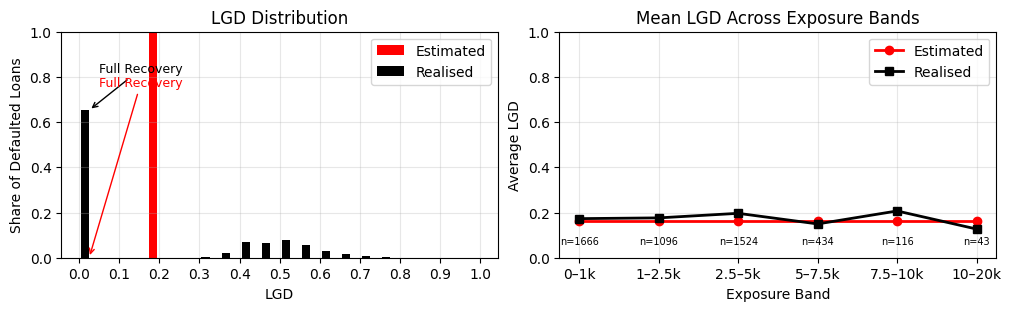

----------------------------------------
TEST
----------------------------------------


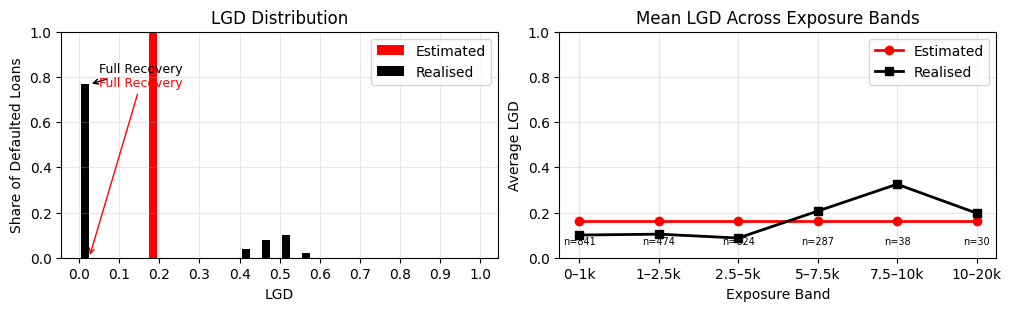

LGD estimation method: univariate
Feature: Age
----------------------------------------
TRAIN
----------------------------------------
MAE         : 0.220
RMSE        : 0.238
CORR        : 0.034
R2          : 0.001
----------------------------------------
----------------------------------------
TEST
----------------------------------------
MAE         : 0.212
RMSE        : 0.226
CORR        : -0.020
R2          : -0.018
----------------------------------------
----------------------------------------
TRAIN
----------------------------------------


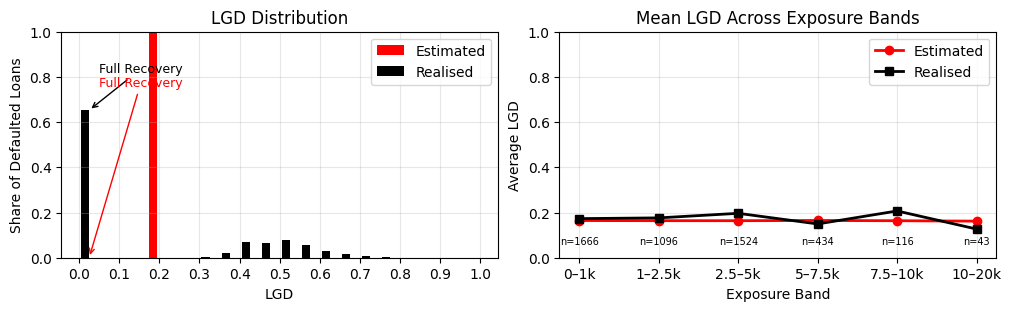

----------------------------------------
TEST
----------------------------------------


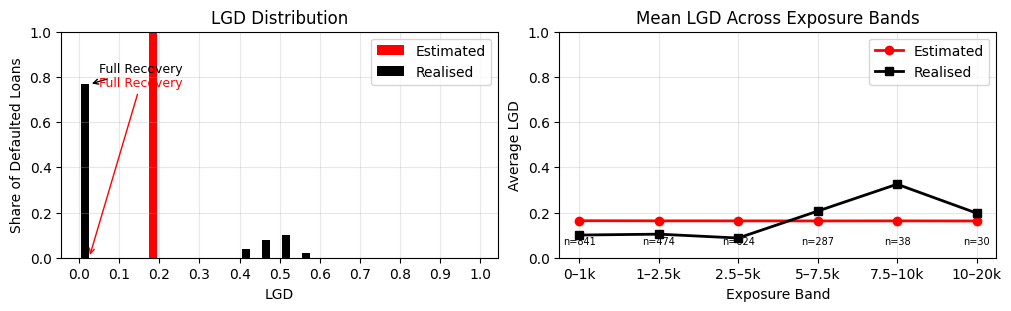

LGD estimation method: univariate
Feature: Gender
----------------------------------------
TRAIN
----------------------------------------
MAE         : 0.193
RMSE        : 0.225
CORR        : 0.326
R2          : 0.106
----------------------------------------
----------------------------------------
TEST
----------------------------------------
MAE         : 0.197
RMSE        : 0.238
CORR        : 0.016
R2          : -0.122
----------------------------------------
----------------------------------------
TRAIN
----------------------------------------


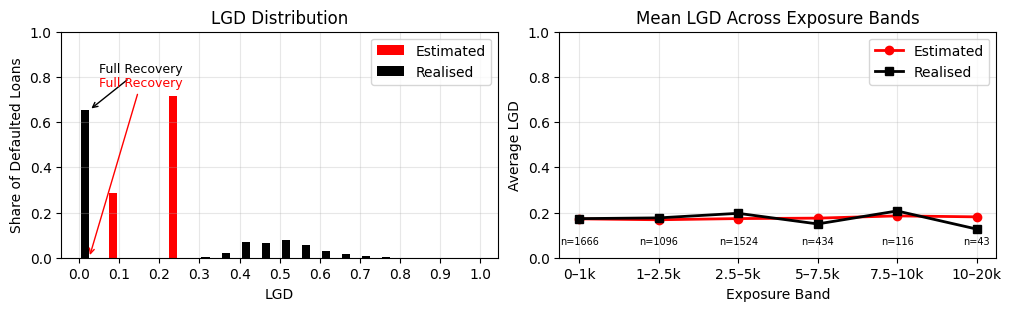

----------------------------------------
TEST
----------------------------------------


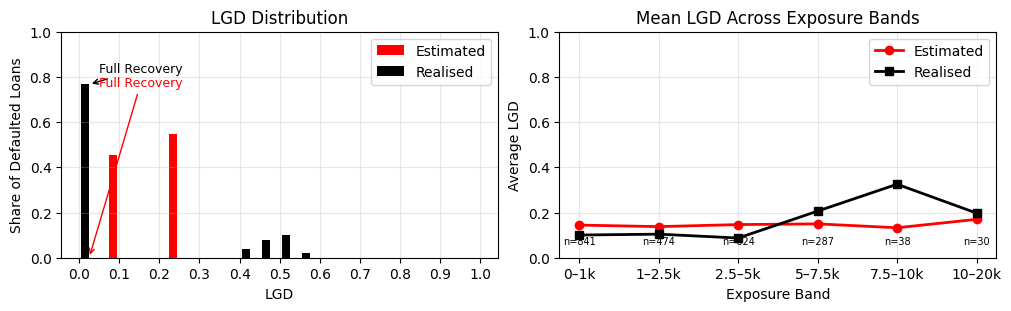

LGD estimation method: univariate
Feature: Amount
----------------------------------------
TRAIN
----------------------------------------
MAE         : 0.197
RMSE        : 0.230
CORR        : 0.272
R2          : 0.068
----------------------------------------
----------------------------------------
TEST
----------------------------------------
MAE         : 0.188
RMSE        : 0.238
CORR        : 0.004
R2          : -0.126
----------------------------------------
----------------------------------------
TRAIN
----------------------------------------


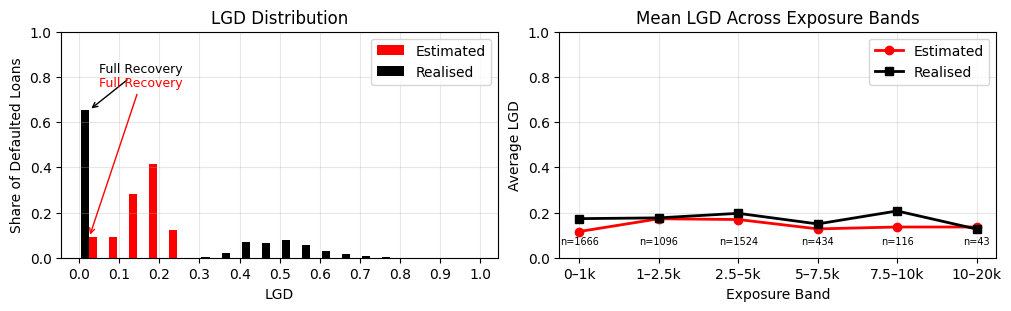

----------------------------------------
TEST
----------------------------------------


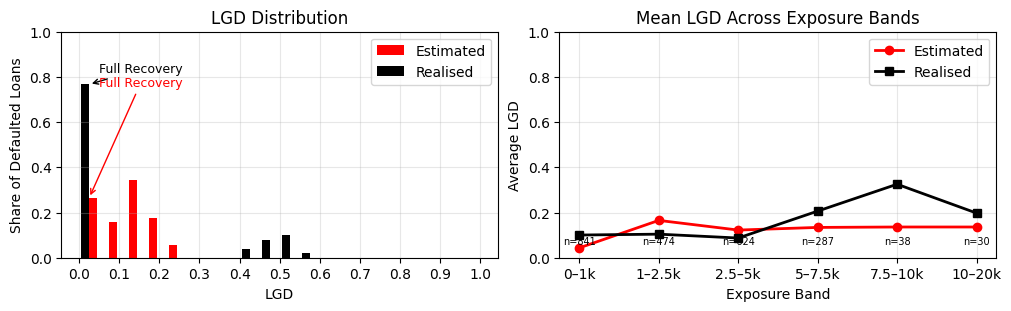

LGD estimation method: univariate
Feature: Interest
----------------------------------------
TRAIN
----------------------------------------
MAE         : 0.221
RMSE        : 0.236
CORR        : 0.157
R2          : 0.020
----------------------------------------
----------------------------------------
TEST
----------------------------------------
MAE         : 0.210
RMSE        : 0.226
CORR        : 0.102
R2          : -0.013
----------------------------------------
----------------------------------------
TRAIN
----------------------------------------


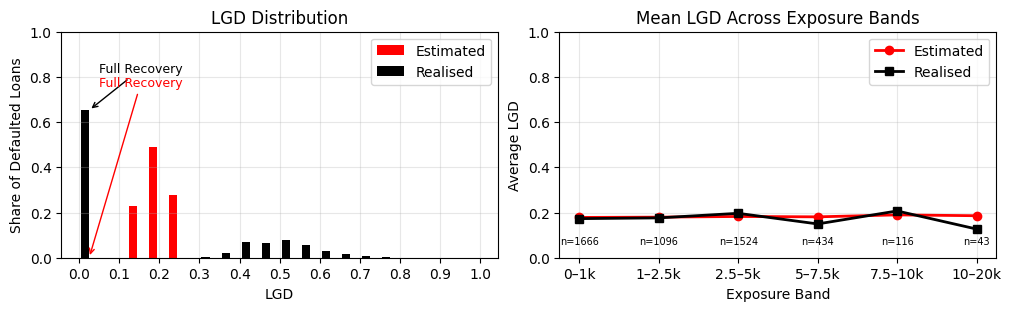

----------------------------------------
TEST
----------------------------------------


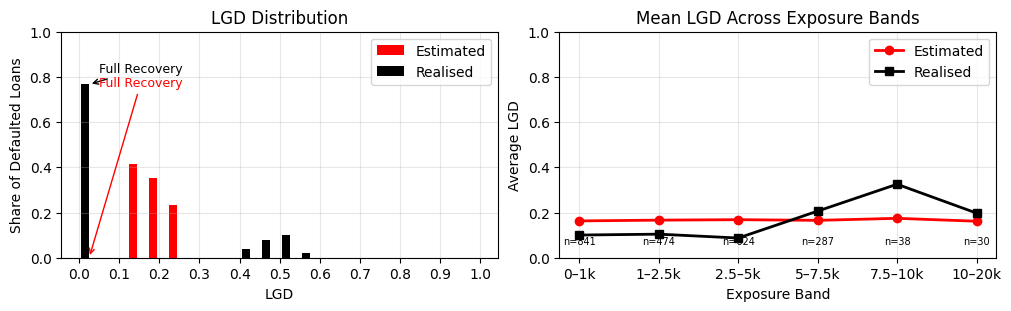

LGD estimation method: univariate
Feature: LoanDuration
----------------------------------------
TRAIN
----------------------------------------
MAE         : 0.218
RMSE        : 0.238
CORR        : 0.066
R2          : 0.004
----------------------------------------
----------------------------------------
TEST
----------------------------------------
MAE         : 0.211
RMSE        : 0.227
CORR        : -0.008
R2          : -0.022
----------------------------------------
----------------------------------------
TRAIN
----------------------------------------


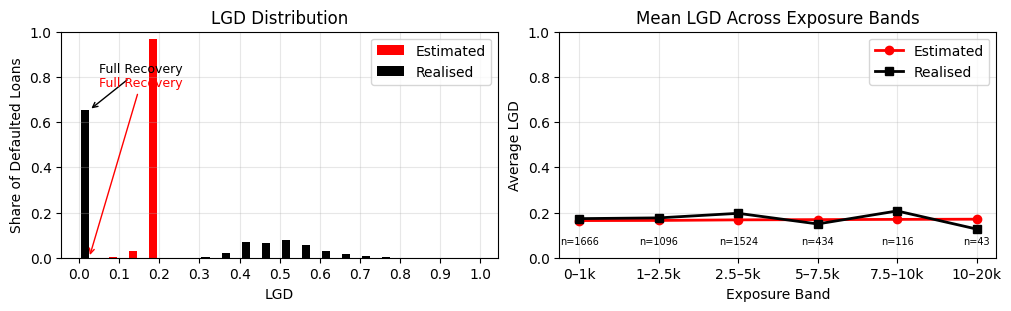

----------------------------------------
TEST
----------------------------------------


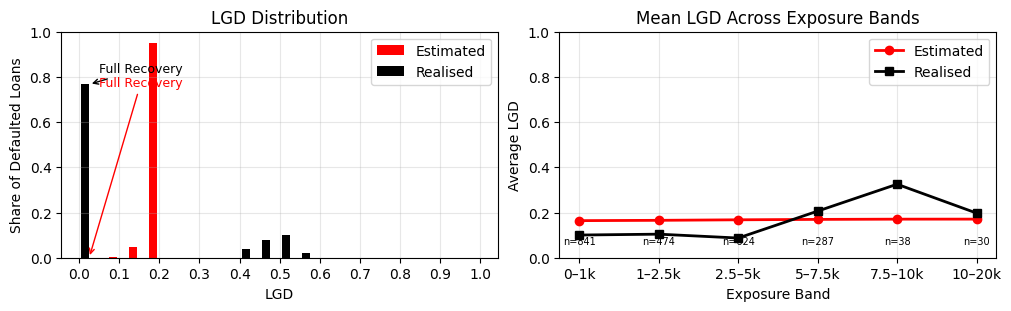

LGD estimation method: univariate
Feature: Education
----------------------------------------
TRAIN
----------------------------------------
MAE         : 0.218
RMSE        : 0.238
CORR        : 0.067
R2          : 0.004
----------------------------------------
----------------------------------------
TEST
----------------------------------------
MAE         : 0.210
RMSE        : 0.226
CORR        : -0.014
R2          : -0.017
----------------------------------------
----------------------------------------
TRAIN
----------------------------------------


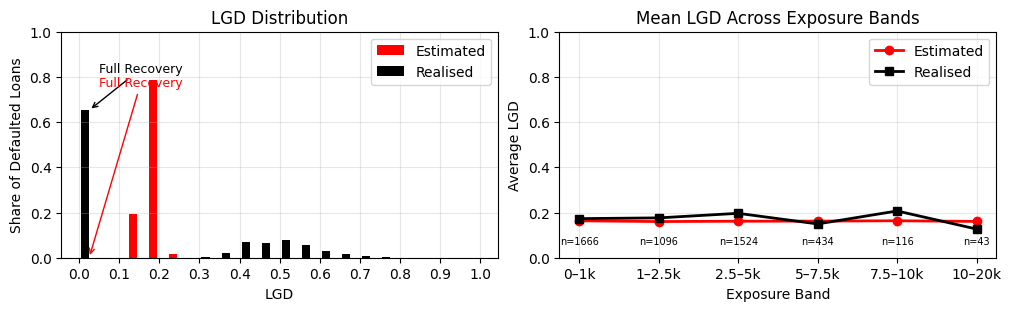

----------------------------------------
TEST
----------------------------------------


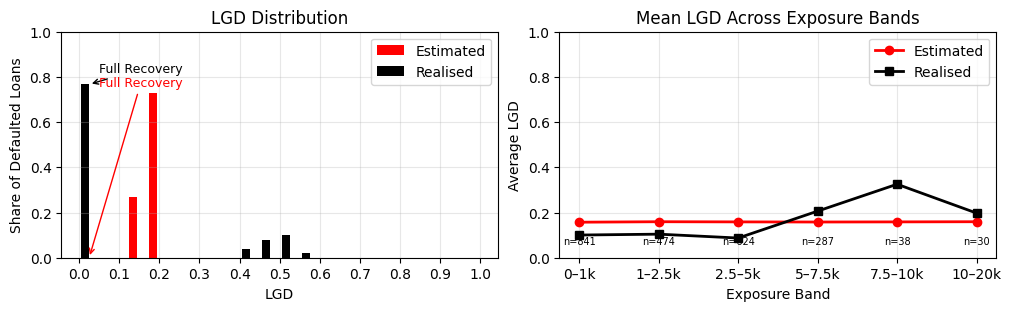

LGD estimation method: univariate
Feature: EmploymentDurationCurrentEmployer
----------------------------------------
TRAIN
----------------------------------------
MAE         : 0.218
RMSE        : 0.238
CORR        : 0.065
R2          : 0.004
----------------------------------------
----------------------------------------
TEST
----------------------------------------
MAE         : 0.210
RMSE        : 0.226
CORR        : -0.028
R2          : -0.015
----------------------------------------
----------------------------------------
TRAIN
----------------------------------------


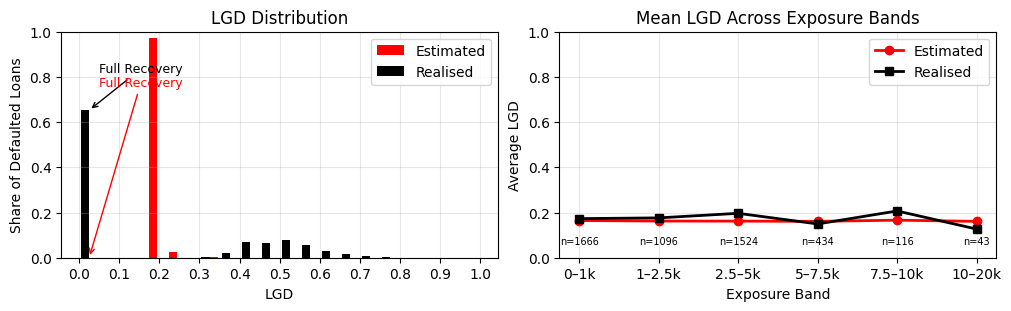

----------------------------------------
TEST
----------------------------------------


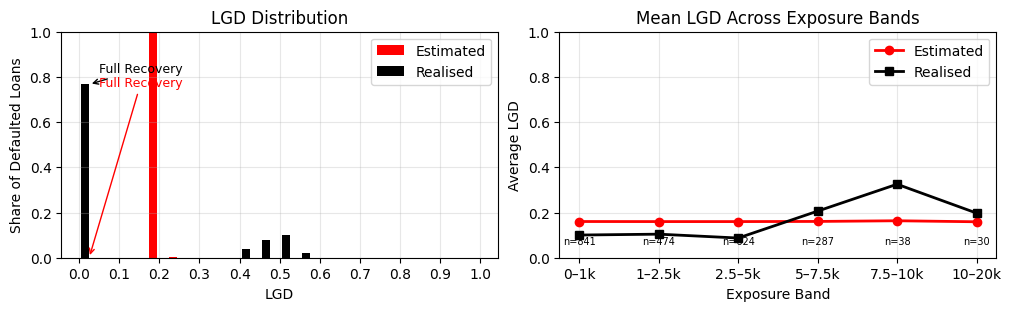

LGD estimation method: univariate
Feature: HomeOwnershipType
----------------------------------------
TRAIN
----------------------------------------
MAE         : 0.219
RMSE        : 0.238
CORR        : 0.048
R2          : 0.002
----------------------------------------
----------------------------------------
TEST
----------------------------------------
MAE         : 0.210
RMSE        : 0.226
CORR        : -0.000
R2          : -0.013
----------------------------------------
----------------------------------------
TRAIN
----------------------------------------


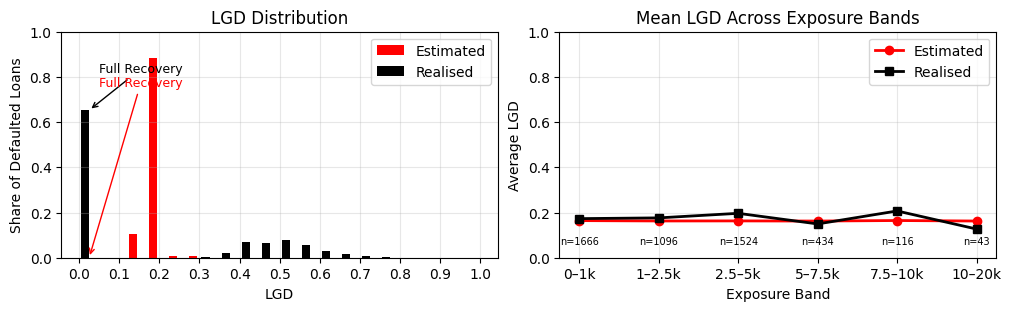

----------------------------------------
TEST
----------------------------------------


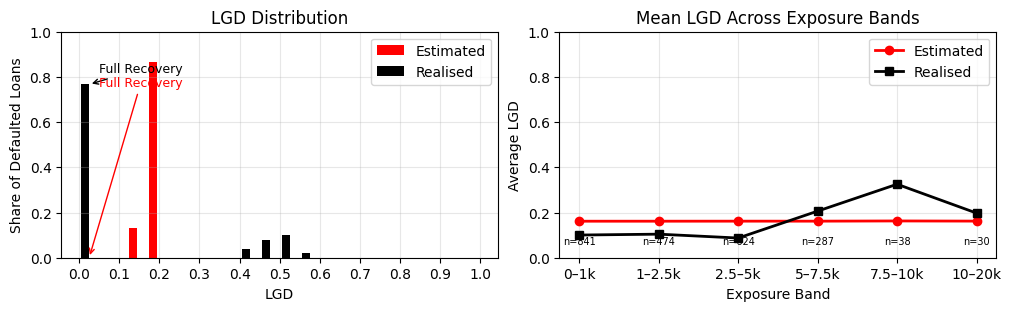

LGD estimation method: univariate
Feature: IncomeTotal
----------------------------------------
TRAIN
----------------------------------------
MAE         : 0.218
RMSE        : 0.238
CORR        : 0.035
R2          : 0.001
----------------------------------------
----------------------------------------
TEST
----------------------------------------
MAE         : 0.210
RMSE        : 0.226
CORR        : -0.029
R2          : -0.015
----------------------------------------
----------------------------------------
TRAIN
----------------------------------------


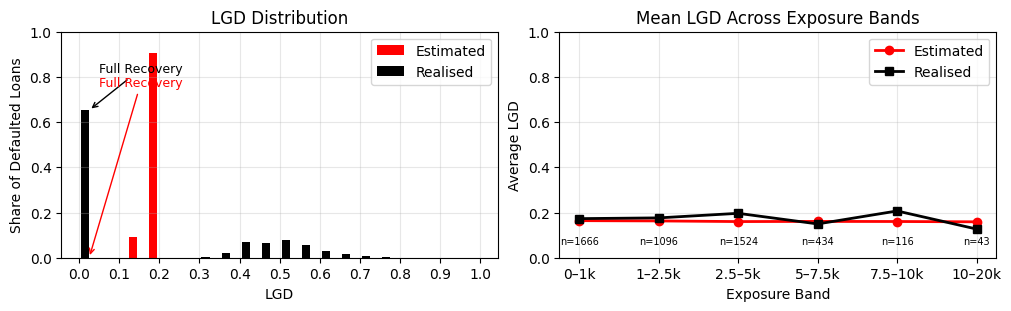

----------------------------------------
TEST
----------------------------------------


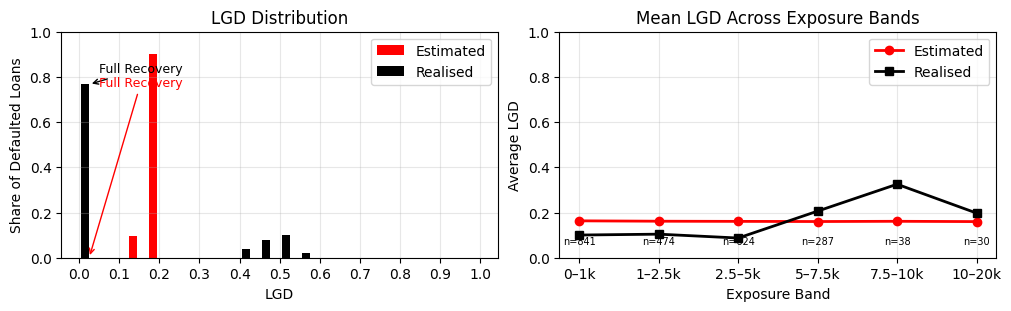

LGD estimation method: univariate
Feature: ExistingLiabilities
----------------------------------------
TRAIN
----------------------------------------
MAE         : 0.221
RMSE        : 0.238
CORR        : 0.020
R2          : -0.000
----------------------------------------
----------------------------------------
TEST
----------------------------------------
MAE         : 0.213
RMSE        : 0.227
CORR        : -0.050
R2          : -0.021
----------------------------------------
----------------------------------------
TRAIN
----------------------------------------


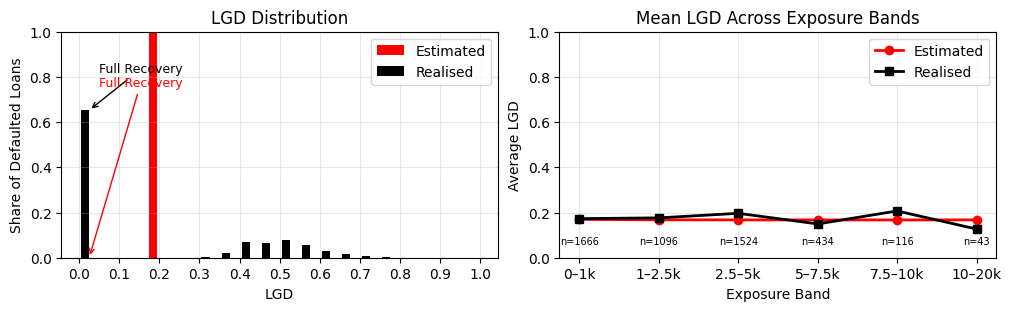

----------------------------------------
TEST
----------------------------------------


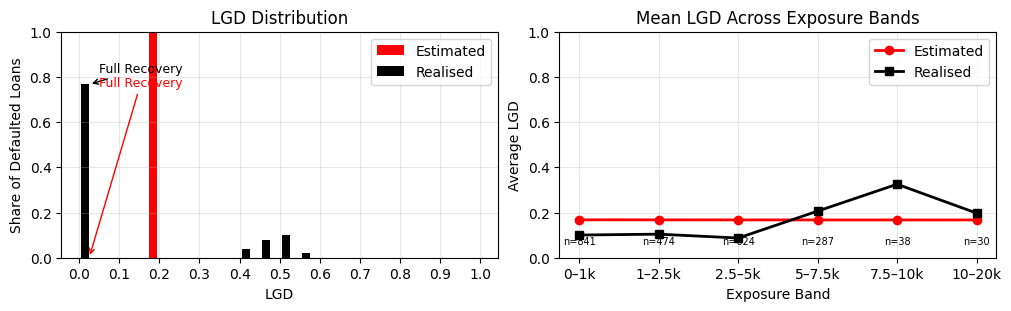

LGD estimation method: univariate
Feature: LiabilitiesTotal
----------------------------------------
TRAIN
----------------------------------------
MAE         : 0.220
RMSE        : 0.238
CORR        : 0.007
R2          : 0.000
----------------------------------------
----------------------------------------
TEST
----------------------------------------
MAE         : 0.212
RMSE        : 0.226
CORR        : -0.001
R2          : -0.016
----------------------------------------
----------------------------------------
TRAIN
----------------------------------------


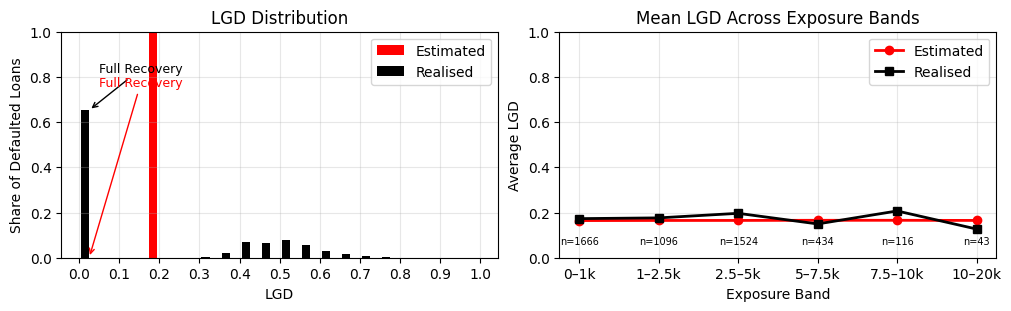

----------------------------------------
TEST
----------------------------------------


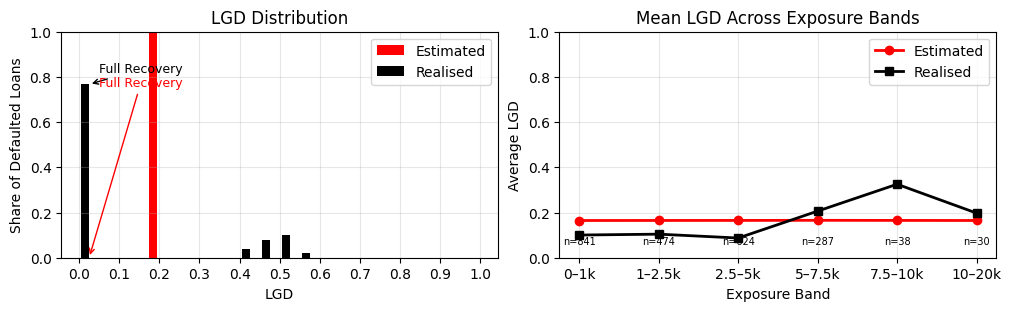

LGD estimation method: univariate
Feature: CreditScoreEeMini
----------------------------------------
TRAIN
----------------------------------------
MAE         : 0.219
RMSE        : 0.238
CORR        : 0.041
R2          : 0.002
----------------------------------------
----------------------------------------
TEST
----------------------------------------
MAE         : 0.211
RMSE        : 0.227
CORR        : -0.067
R2          : -0.022
----------------------------------------
----------------------------------------
TRAIN
----------------------------------------


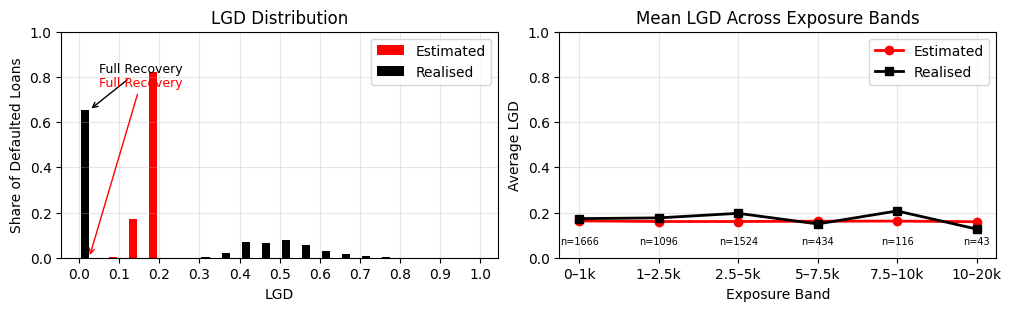

----------------------------------------
TEST
----------------------------------------


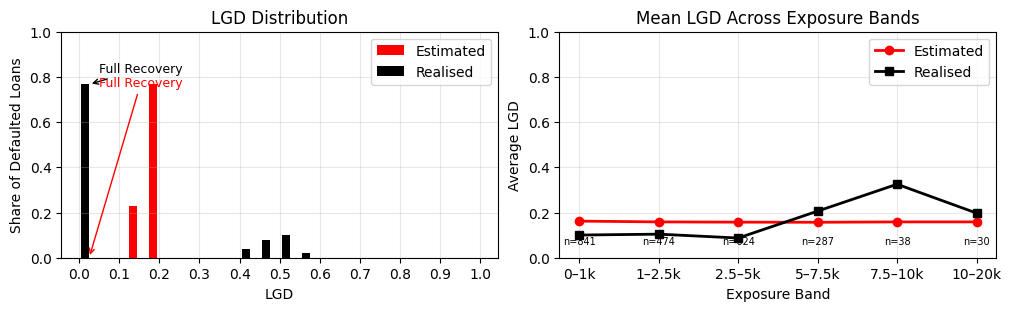

LGD estimation method: univariate
Feature: NoOfPreviousLoansBeforeLoan
----------------------------------------
TRAIN
----------------------------------------
MAE         : 0.220
RMSE        : 0.238
CORR        : 0.034
R2          : 0.001
----------------------------------------
----------------------------------------
TEST
----------------------------------------
MAE         : 0.212
RMSE        : 0.226
CORR        : 0.021
R2          : -0.017
----------------------------------------
----------------------------------------
TRAIN
----------------------------------------


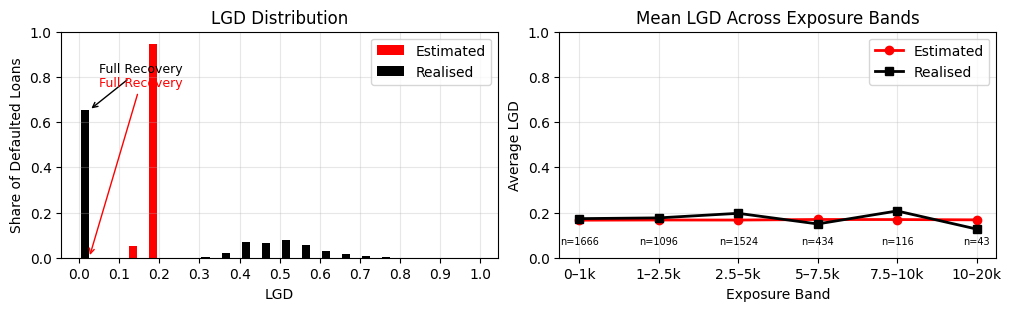

----------------------------------------
TEST
----------------------------------------


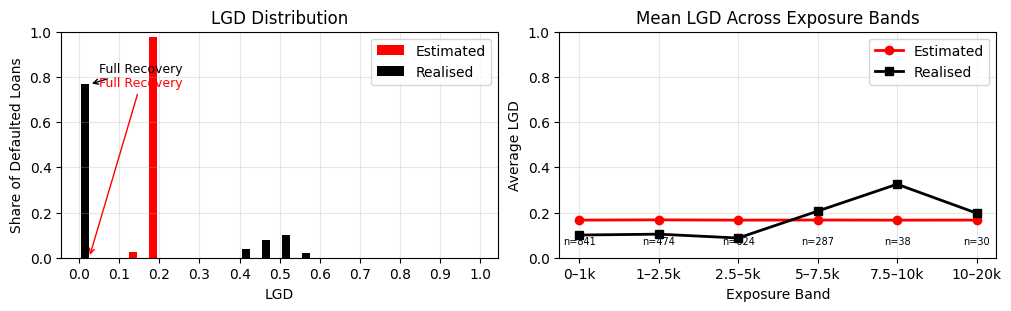

LGD estimation method: univariate
Feature: AmountOfPreviousLoansBeforeLoan
----------------------------------------
TRAIN
----------------------------------------
MAE         : 0.220
RMSE        : 0.238
CORR        : 0.027
R2          : 0.001
----------------------------------------
----------------------------------------
TEST
----------------------------------------
MAE         : 0.212
RMSE        : 0.226
CORR        : 0.015
R2          : -0.018
----------------------------------------
----------------------------------------
TRAIN
----------------------------------------


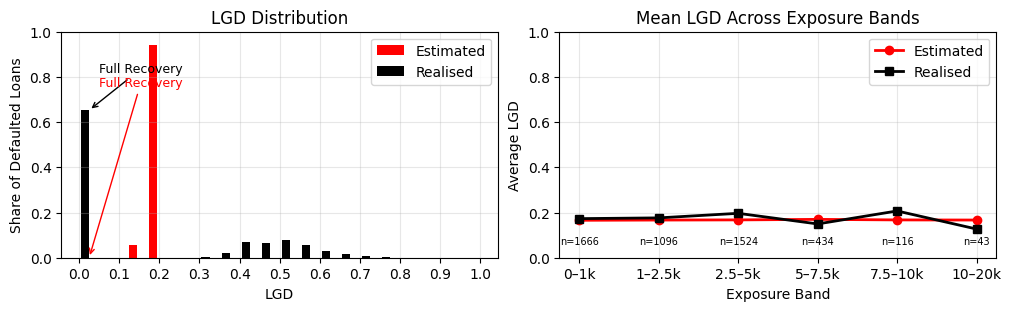

----------------------------------------
TEST
----------------------------------------


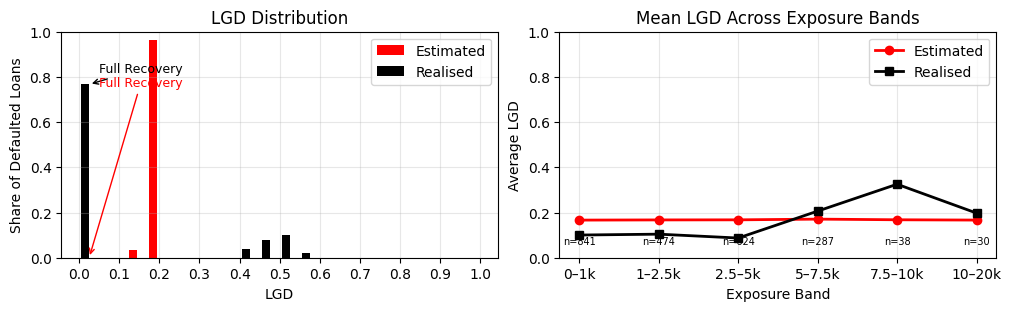

,Dataset,MAE,RMSE,CORR,R2,Experiment,Method,Variable
28,TRAIN,0.220063,0.238144,2.693805e-02,0.000593,experiment O,univariate,AmountOfPreviousLoansBeforeLoan
29,TEST,0.212418,0.226341,1.512574e-02,-0.018028,experiment O,univariate,AmountOfPreviousLoansBeforeLoan
26,TRAIN,0.220038,0.238098,3.422735e-02,0.000981,experiment N,univariate,NoOfPreviousLoansBeforeLoan
27,TEST,0.212327,0.226280,2.114028e-02,-0.017481,experiment N,univariate,NoOfPreviousLoansBeforeLoan
24,TRAIN,0.218799,0.238015,4.092642e-02,0.001675,experiment M,univariate,CreditScoreEeMini
25,TEST,0.211261,0.226769,-6.677684e-02,-0.021880,experiment M,univariate,CreditScoreEeMini
22,TRAIN,0.219736,0.238213,7.263948e-03,0.000017,experiment L,univariate,LiabilitiesTotal
23,TEST,0.211662,0.226118,-1.448513e-03,-0.016023,experiment L,univariate,LiabilitiesTotal
20,TRAIN,0.220822,0.238227,2.000090e-02,-0.000099,experiment K,univariate,ExistingLiabilities
21,TEST,0.213163,0.226640,-4.977496e-02,-0.020717,experiment K,univariate,ExistingLiabilities


In [18]:
# loop on experiments

for experiment, method, variable in experiments:

    # fit lgds on training dataset
    
    lgd_model = fit_lgd(ds_trai, method=method, one_variable=variable)

    # transform lgds on training dataset 

    ds_trai   = transform_lgd(ds_trai, lgd_model)

    # transform lgds on testing dataset

    ds_test   = transform_lgd(ds_test, lgd_model)

    # evaluate: calculate metrics

    metrics_trai = my_regression_metrics(ds_trai["LossGivenDefault"], ds_trai["LGD"], dataset_name="TRAIN", verbose=True)   
    metrics_test = my_regression_metrics(ds_test["LossGivenDefault"], ds_test["LGD"], dataset_name="TEST" , verbose=True)   

    # append

    metrics_trai["Experiment"] = experiment
    metrics_trai["Dataset"]    = "TRAIN"
    metrics_trai["Method"]     = method
    metrics_trai["Variable"]   = variable
    experiment_metrics.append(metrics_trai)

    metrics_test["Experiment"] = experiment
    metrics_test["Dataset"]    = "TEST"
    metrics_test["Method"]     = method
    metrics_test["Variable"]   = variable
    experiment_metrics.append(metrics_test)

    # evaluate: visually

    print("-" * 40)
    print("TRAIN")
    print("-" * 40)
    compare_lgd_distributions(ds_trai)
    print("-" * 40)
    print("TEST")
    print("-" * 40)
    compare_lgd_distributions(ds_test)

# put together

experiment_metrics = pd.DataFrame(experiment_metrics)
display(experiment_metrics.sort_values(by=["Experiment", "Dataset"], ascending=[False, False]))


#### Select & Export

In [19]:
# model selector

selection_table, best_model = model_selector(experiment_metrics, metric="CORR")

display(selection_table)
display(best_model)

Dataset,Experiment,Method,Variable,Test CORR,Train CORR,Generalization Gap
0,experiment A,historical_avg,NaN,-5.369107e-15,1.810936e-15,7.180043e-15
1,experiment B,univariate,Age,-1.965199e-02,3.371288e-02,5.336488e-02
2,experiment C,univariate,Gender,1.590821e-02,3.262753e-01,3.103671e-01
3,experiment D,univariate,Amount,3.621250e-03,2.722665e-01,2.686452e-01
4,experiment E,univariate,Interest,1.016725e-01,1.572711e-01,5.559858e-02
5,experiment F,univariate,LoanDuration,-7.904517e-03,6.598860e-02,7.389311e-02
6,experiment G,univariate,Education,-1.385137e-02,6.693180e-02,8.078317e-02
7,experiment H,univariate,EmploymentDurationCurrentEmployer,-2.762621e-02,6.529829e-02,9.292450e-02
8,experiment I,univariate,HomeOwnershipType,-2.981702e-04,4.758348e-02,4.788165e-02
9,experiment J,univariate,IncomeTotal,-2.865296e-02,3.450498e-02,6.315793e-02


Dataset,Experiment,Method,Variable,Test CORR,Train CORR,Generalization Gap
4,experiment E,univariate,Interest,0.101673,0.157271,0.055599


Although the 'interest rate' gives the best performance, it reflects the lender's risk-based pricing policy and therefore already contains embedded credit-risk information. For demonstration purposes, the final LGD model should be selected from variables describing the borrower or the loan itself.

Next steps:
1. linear regression
1. gradient boosting

In [20]:
# model export

#joblib.dump(lgd_model, "../models/lgd_model_Amount.pkl")